Agente de monedas Ocultas

In [39]:
import numpy as np
import math
import matplotlib.pyplot as plt

np.random.seed(42)

Entorno: tablero de 5x5, el agente cava en cualquier hueco para encontrar la moneda, la mejor casilla es la que tiene mayor probabilidad de tener la moneda

In [40]:
tamano = 5
numeroCasillas = tamano*tamano

probabilida_real  = np.random.uniform(0,0.5,numeroCasillas)

mejorCasilla = np.argmax(probabilida_real)
print("Tablero")
print(f"Dimensiones: {tamano}x{tamano} = {numeroCasillas} casillas")

for i in range(tamano):
    fila = probabilida_real[i*tamano:(i+1)*tamano]
    print(f"  Fila {i}: {[f'{p:.2f}' for p in fila]}")
print(f"\nMejor casilla: fila {mejorCasilla//tamano}, columna {mejorCasilla%tamano} (probabilidad = {probabilida_real[mejorCasilla]:.3f})")

Tablero
Dimensiones: 5x5 = 25 casillas
  Fila 0: ['0.19', '0.48', '0.37', '0.30', '0.08']
  Fila 1: ['0.08', '0.03', '0.43', '0.30', '0.35']
  Fila 2: ['0.01', '0.48', '0.42', '0.11', '0.09']
  Fila 3: ['0.09', '0.15', '0.26', '0.22', '0.15']
  Fila 4: ['0.31', '0.07', '0.15', '0.18', '0.23']

Mejor casilla: fila 2, columna 1 (probabilidad = 0.485)


Algoritmo del Gradiente

In [41]:
def softmax(x):
    return np.exp(x) / sum(np.exp(x))

In [42]:
partidas = 500
turnos = 200
alphas_grad = [0.1, 0.4]
nombres_grad = [f'Gradiente (α={a})' for a in alphas_grad]
recompensas_grad = np.zeros((len(nombres_grad), turnos))
optimas_grad = np.zeros((len(nombres_grad), turnos))

for partida in range(partidas):
    for i, alfa in enumerate(alphas_grad):
        H = np.zeros(numeroCasillas)
        recompensas_historial = []
        for turno in range(turnos):
            probabilidades = softmax(H)
            casilla = np.random.choice(numeroCasillas, p=probabilidades)
            recompensa = 1 if np.random.uniform() < probabilida_real[casilla] else 0
            recompensas_historial.append(recompensa)
            recompensa_promedio = np.mean(recompensas_historial)
            for j in range(numeroCasillas):
                if j == casilla:
                    H[j] += alfa * (recompensa - recompensa_promedio) * (1 - probabilidades[j])
                else:
                    H[j] -= alfa * (recompensa - recompensa_promedio) * probabilidades[j]

            recompensas_grad[i][turno] += recompensa
            optimas_grad[i][turno] += (1 if casilla == mejorCasilla else 0)

recompensas_grad /= partidas
optimas_grad /= partidas

print(recompensas_grad)
print(optimas_grad)

[[0.258 0.218 0.218 0.212 0.212 0.234 0.224 0.228 0.21  0.24  0.202 0.212
  0.236 0.256 0.22  0.2   0.202 0.218 0.202 0.176 0.2   0.232 0.206 0.238
  0.184 0.216 0.23  0.212 0.222 0.176 0.24  0.224 0.246 0.244 0.238 0.224
  0.236 0.214 0.24  0.252 0.22  0.228 0.224 0.248 0.244 0.236 0.212 0.204
  0.198 0.228 0.242 0.228 0.234 0.2   0.214 0.236 0.246 0.24  0.228 0.238
  0.222 0.244 0.234 0.224 0.254 0.216 0.218 0.232 0.224 0.218 0.208 0.192
  0.236 0.218 0.196 0.232 0.226 0.226 0.24  0.24  0.23  0.214 0.208 0.236
  0.224 0.256 0.202 0.234 0.218 0.226 0.23  0.204 0.212 0.248 0.182 0.224
  0.232 0.238 0.24  0.206 0.208 0.25  0.204 0.232 0.234 0.244 0.214 0.206
  0.24  0.234 0.274 0.234 0.266 0.214 0.228 0.222 0.242 0.26  0.222 0.216
  0.236 0.196 0.232 0.214 0.228 0.242 0.232 0.24  0.204 0.23  0.24  0.218
  0.204 0.228 0.236 0.216 0.262 0.23  0.23  0.234 0.2   0.25  0.248 0.216
  0.248 0.232 0.212 0.222 0.268 0.218 0.278 0.258 0.2   0.232 0.244 0.238
  0.248 0.254 0.256 0.224 0.252 0.244 

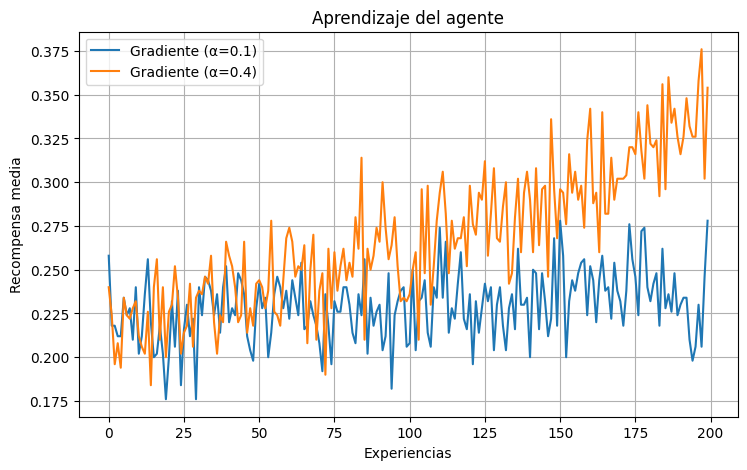

In [43]:
plt.figure(figsize=(8.5, 5))
for i, nombre in enumerate(nombres_grad):
    plt.plot(recompensas_grad[i], label=nombre)
plt.legend()
plt.grid(True)
plt.xlabel('Experiencias')
plt.ylabel('Recompensa media')
plt.title('Aprendizaje del agente')
plt.show()

In [44]:
import pandas as pd

tabla_q = pd.DataFrame({
    'casilla': [f'({i // tamano}, {i % tamano})' for i in range(numeroCasillas)],
    'valor_aprendido': softmax(H)
}).sort_values('valor_aprendido', ascending=False).reset_index(drop=True)

tabla_q

,casilla,valor_aprendido
0,"(2, 1)",0.137209
1,"(0, 1)",0.118285
2,"(1, 3)",0.093263
3,"(1, 4)",0.061131
4,"(0, 3)",0.054433
5,"(0, 2)",0.054372
6,"(1, 2)",0.043204
7,"(3, 2)",0.035818
8,"(0, 0)",0.034476
9,"(4, 0)",0.032142
